# Exp1 RL–Memory Simulation

## Goal and Hypotheses

This notebook simulates three encoding-drift hypotheses and compares their
behavioural predictions for event-boundary memory.

| Label | Description |
|-------|-------------|
| **H0 (Baseline)** | Normal boundary drift increase, modulated by |RPE| |
| **H1** | Smaller boundary-specific drift increase |
| **H2** | Same boundary increment but global downward bias shift |

## Imports and setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    get_default_task_config, get_default_model_config,
    get_hypothesis_params, get_default_sim_config,
)
from src.task_design import build_trial_dataframe
from src.simulator import run_all_hypotheses
from src.metrics import summarize_all_metrics, compute_subject_summary
from src import plotting
from src.utils import ensure_dir, save_dataframe, save_json

# Output dirs
for d in ['../results/tables', '../results/figures', '../results/serialized']:
    ensure_dir(d)

%matplotlib inline

## Define configs

In [2]:
task_cfg  = get_default_task_config()
model_cfg = get_default_model_config()
hyp       = get_hypothesis_params()
sim_cfg   = get_default_sim_config()

print('Task config: ', task_cfg)
print('Model config:', model_cfg)
print('Hypothesis:  ', hyp)
print('Sim config:  ', sim_cfg)

Task config:  TaskConfig(n_lists=4, items_per_list=24, items_per_train=6, reward_mean=50.0, reward_std=20.0, initial_value=50.0)
Model config: ModelConfig(alpha=0.3, beta_base=0.5, delta_boundary=0.25, rpe_drift_weight=0.15, recall_intercept=-0.5, recall_drift_weight=2.0, recall_noise_std=0.05)
Hypothesis:   HypothesisParams(h1_delta_boundary=0.1, h2_bias_shift=0.15)
Sim config:   SimConfig(n_subjects=100, seed=42, hypothesis_names=('baseline', 'H1_smaller_boundary', 'H2_global_reduction'))


## Build & inspect Exp1 schedule (single subject preview)

In [3]:
rng = np.random.default_rng(0)
demo_df = build_trial_dataframe(task_cfg, rng=rng, alpha=model_cfg.alpha)
print(f'{len(demo_df)} trials, {demo_df["is_boundary"].sum()} boundaries')
demo_df.head(15)

96 trials, 12 boundaries


,trial,list_id,item_id,within_list_pos,train_id,within_train_pos,is_boundary,reward,expected_value,outcome_rpe,abs_outcome_rpe
0,0,0,0,0,0,0,0,52.51,50.0000,2.5100,2.5100
1,1,0,1,1,0,1,0,47.36,50.7530,-3.3930,3.3930
2,2,0,2,2,0,2,0,62.81,49.7351,13.0749,13.0749
3,3,0,3,3,0,3,0,52.10,53.6576,-1.5576,1.5576
4,4,0,4,4,0,4,0,39.29,53.1903,-13.9003,13.9003
5,5,0,5,5,0,5,0,57.23,49.0202,8.2098,8.2098
6,6,0,6,6,1,0,1,76.08,51.4831,24.5969,24.5969
7,7,0,7,7,1,1,0,68.94,58.8622,10.0778,10.0778
8,8,0,8,8,1,2,0,35.93,61.8855,-25.9555,25.9555
9,9,0,9,9,1,3,0,24.69,54.0989,-29.4089,29.4089


## Run simulations for all three hypotheses

In [4]:
all_trials = run_all_hypotheses(task_cfg, model_cfg, hyp, sim_cfg)
print(f'Total rows: {len(all_trials):,}')
all_trials.head()

  Simulating baseline (100 subjects) …
  Simulating H1_smaller_boundary (100 subjects) …
  Simulating H2_global_reduction (100 subjects) …
  Done.
Total rows: 28,800


,trial,list_id,item_id,within_list_pos,train_id,within_train_pos,is_boundary,reward,expected_value,outcome_rpe,abs_outcome_rpe,encoding_drift,recall_prob,recalled,hypothesis,subject_id
0,0,0,0,0,0,0,0,46.20,50.0000,-3.8000,3.8000,0.505700,0.634004,0,baseline,0
1,1,0,1,1,0,1,0,29.24,48.8600,-19.6200,19.6200,0.529430,0.637014,1,baseline,0
2,2,0,2,2,0,2,0,53.25,42.9740,10.2760,10.2760,0.515414,0.635019,1,baseline,0
3,3,0,3,3,0,3,0,47.65,46.0568,1.5932,1.5932,0.502390,0.623196,0,baseline,0
4,4,0,4,4,0,4,0,83.96,46.5348,37.4252,37.4252,0.556138,0.654818,1,baseline,0


In [5]:
# Save trial-level data
save_dataframe(all_trials, '../results/serialized/trial_level_simulations.csv')

  Saved 28800 rows → ../results/serialized/trial_level_simulations.csv


## Compute all metrics

In [6]:
subj_summary, hyp_summary, spc_df, train_df = summarize_all_metrics(all_trials)

print('=== Hypothesis-level summary ===')
hyp_summary

=== Hypothesis-level summary ===


,hypothesis,overall_recall_mean,overall_recall_sem,nonboundary_recall_mean,nonboundary_recall_sem,boundary_recall_mean,boundary_recall_sem,boundary_advantage_mean,boundary_advantage_sem,mean_nonboundary_drift_mean,...,mean_boundary_drift_mean,mean_boundary_drift_sem,drift_boundary_contrast_mean,drift_boundary_contrast_sem,mean_abs_rpe_mean,mean_abs_rpe_sem,mean_drift_mean,mean_drift_sem,rpe_recall_r_mean,rpe_recall_r_sem
0,H1_smaller_boundary,0.636667,0.005119,0.629286,0.005431,0.688333,0.014244,0.059048,0.015108,0.525626,...,0.625068,0.000519,0.099443,0.000576,17.037422,0.119979,0.538056,0.00018,0.037871,0.009477
1,H2_global_reduction,0.576146,0.004529,0.560119,0.004838,0.688333,0.014244,0.128214,0.015217,0.375626,...,0.625068,0.000519,0.249443,0.000576,17.037422,0.119979,0.406806,0.00018,0.030951,0.010141
2,baseline,0.644583,0.005123,0.629286,0.005431,0.751667,0.013761,0.122381,0.014574,0.525626,...,0.775068,0.000519,0.249443,0.000576,17.037422,0.119979,0.556806,0.00018,0.037239,0.009437


In [7]:
# Save tables
save_dataframe(subj_summary, '../results/tables/subject_summary_metrics.csv')
save_dataframe(hyp_summary, '../results/tables/hypothesis_summary_metrics.csv')

  Saved 300 rows → ../results/tables/subject_summary_metrics.csv
  Saved 3 rows → ../results/tables/hypothesis_summary_metrics.csv


## Manipulation checks

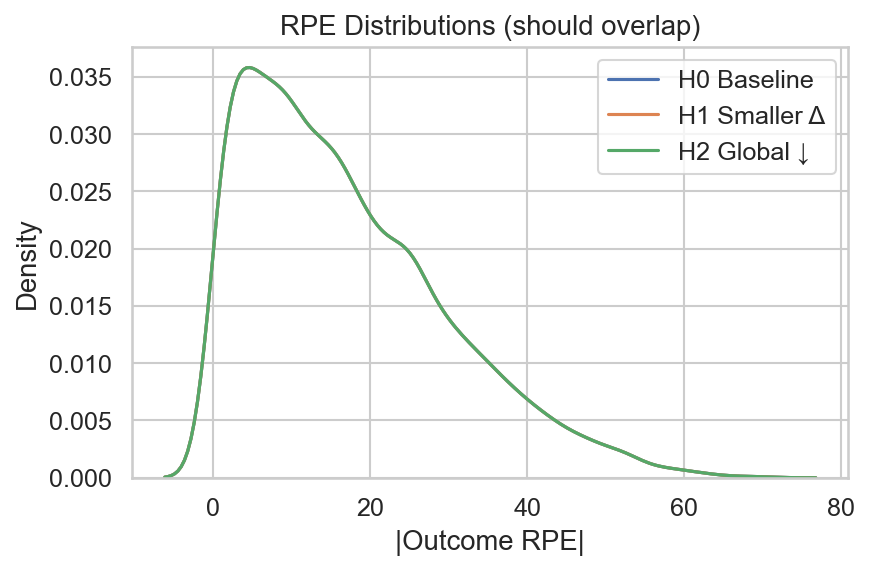

In [8]:
fig_rpe = plotting.plot_rpe_distributions(all_trials)
plt.show()

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER])


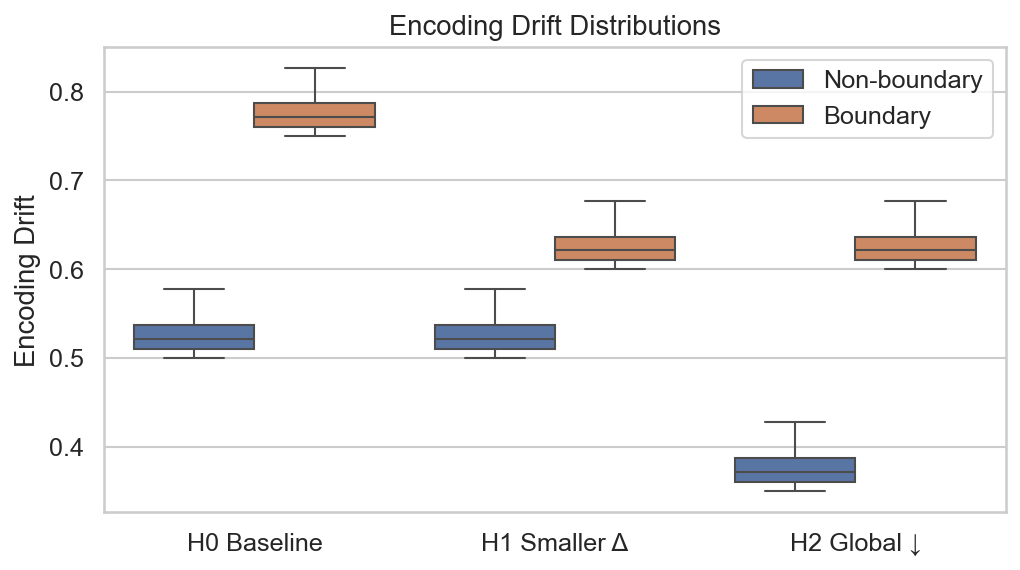

In [9]:
fig_drift = plotting.plot_drift_distributions(all_trials)
plt.show()

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER])


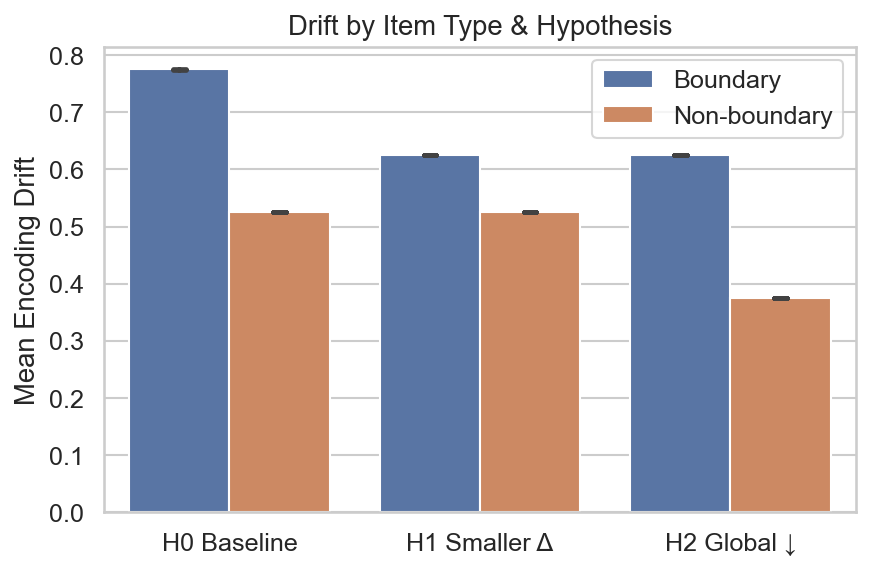

In [10]:
fig_drift_bar = plotting.plot_mean_drift_by_item_type(subj_summary)
plt.show()

## Memory outputs

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER])


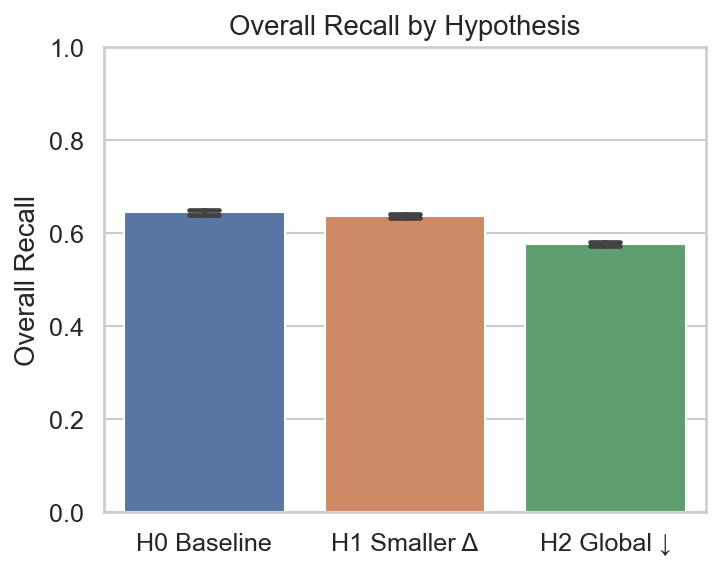

In [11]:
fig_overall = plotting.plot_overall_recall(subj_summary)
plt.show()

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER])


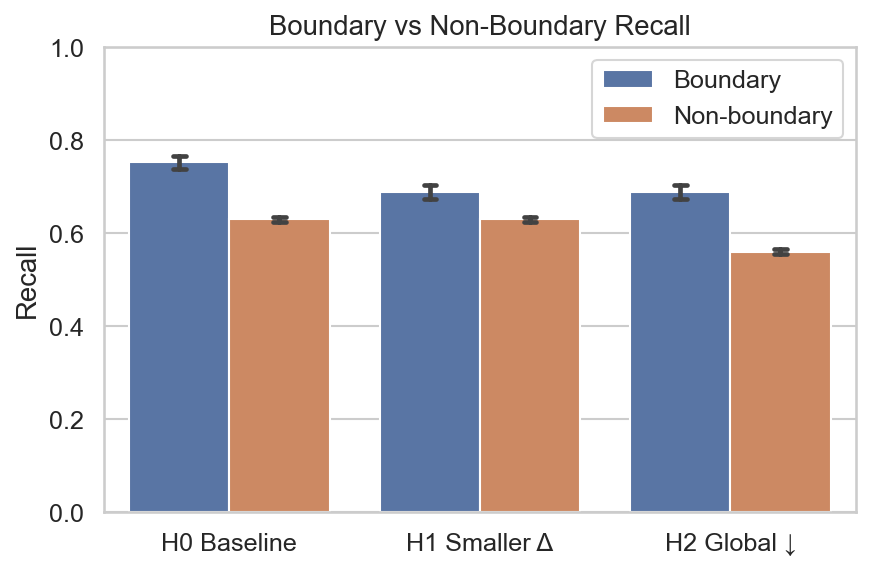

In [12]:
fig_bnd = plotting.plot_boundary_recall(subj_summary)
plt.show()

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER])


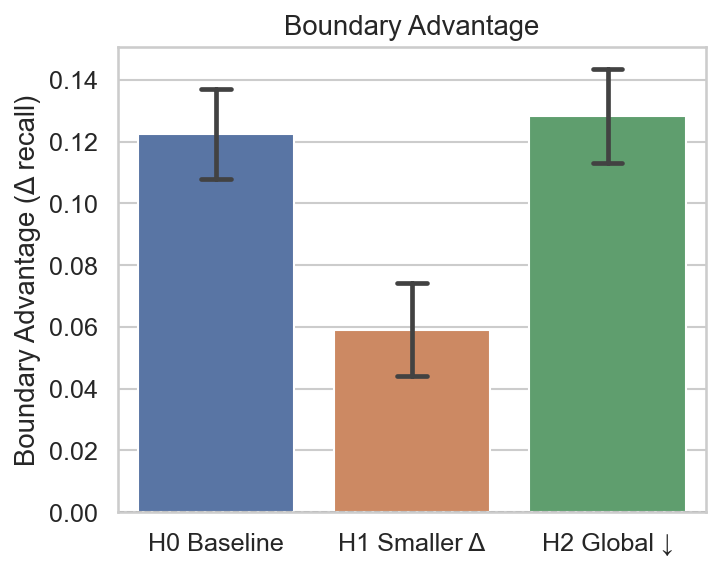

In [13]:
fig_adv = plotting.plot_boundary_advantage(subj_summary)
plt.show()

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:111: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.tight_layout()
/opt/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


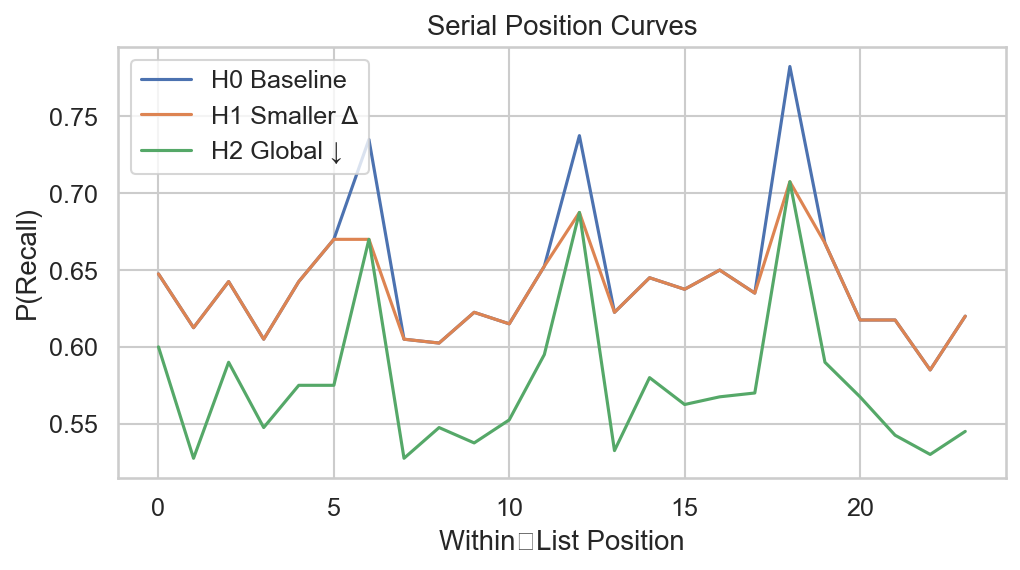

In [14]:
fig_spc = plotting.plot_serial_position(spc_df)
plt.show()

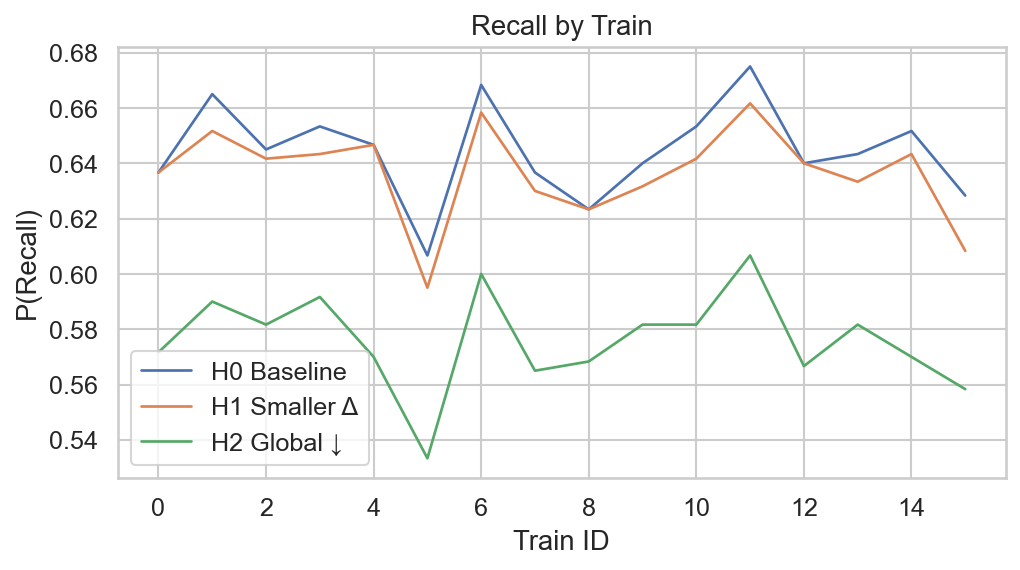

In [15]:
fig_train = plotting.plot_recall_by_train(train_df)
plt.show()

## Compact comparison panel

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER], fontsize=8)
/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:237: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_hyp_label(h) for h in _HYP_ORDER], fontsize=8)
/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim

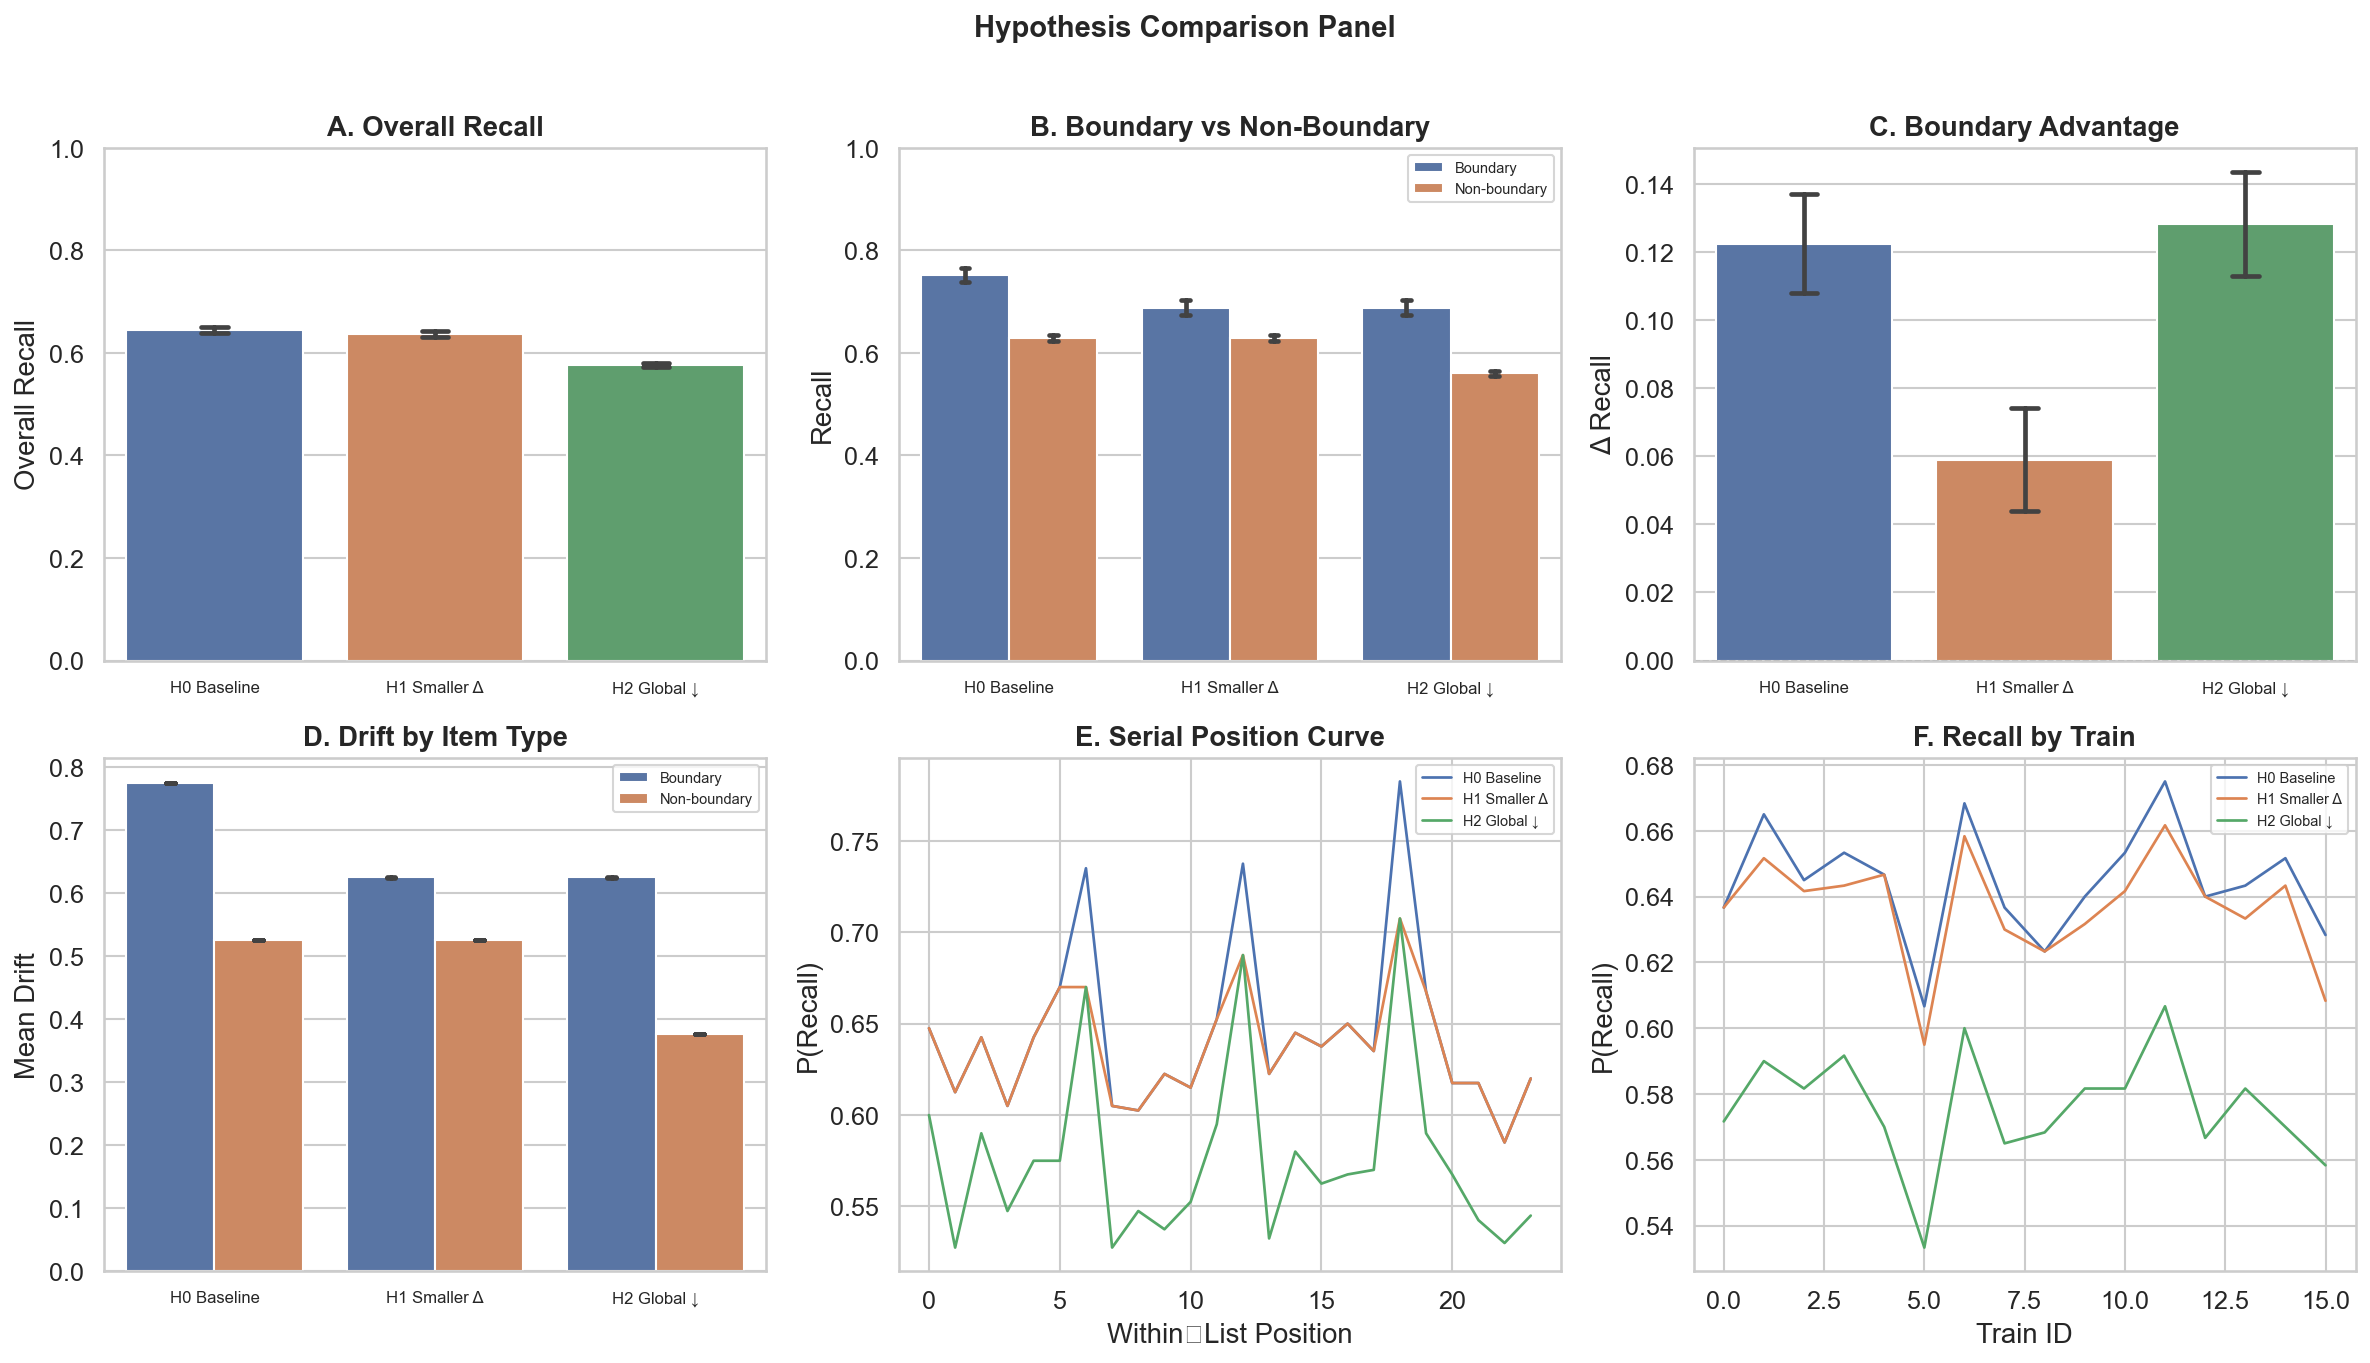

In [16]:
fig_panel = plotting.make_compact_comparison_panel(
    subj_summary, spc_df, train_df, all_trials
)
plt.show()

## Save all figures

In [17]:
figures = {
    'rpe_distributions': fig_rpe,
    'drift_distributions': fig_drift,
    'drift_by_item_type': fig_drift_bar,
    'overall_recall': fig_overall,
    'boundary_vs_nonboundary': fig_bnd,
    'boundary_advantage': fig_adv,
    'serial_position': fig_spc,
    'recall_by_train': fig_train,
    'compact_panel': fig_panel,
}
plotting.save_all_figures(figures, '../results/figures')

/Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/RL_boundary_sim/src/plotting.py:321: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.savefig(out_dir / f"{name}.png")


  Saved 9 figures to ../results/figures


## Interpretation

Key questions to answer from the comparison panel:

- **Does H1 selectively weaken the boundary benefit?**  
  Check whether boundary advantage shrinks under H1 while non-boundary recall stays roughly the same as baseline.

- **Does H2 produce a global downward recall shift?**  
  Check whether both boundary and non-boundary recall drop, while boundary advantage is relatively preserved.

- **Are the hypotheses separable on the chosen metrics?**  
  The most diagnostic pair is *(overall recall, boundary advantage)*: H1 should primarily affect boundary advantage; H2 should primarily affect overall recall.